<a href="https://colab.research.google.com/github/LK-Prajapati07/AI-Adaptive-Quiz-and-Learning-Proctor-Platform/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = sns.load_dataset('titanic')

In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
df_clean = df.drop(['class', 'who', 'embark_town', 'alive'],axis=1)

In [ ]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
df['age'] = df['age'].fillna(df['age'].median())

In [ ]:
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [ ]:
df = df.drop(columns=['class', 'who', 'embark_town', 'alive'])

In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
adult_male,0
deck,688


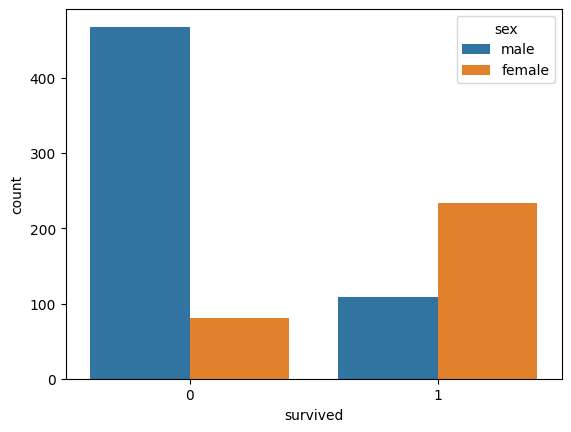

In [ ]:
sns.countplot(x='survived', hue='sex', data=df)
plt.show()

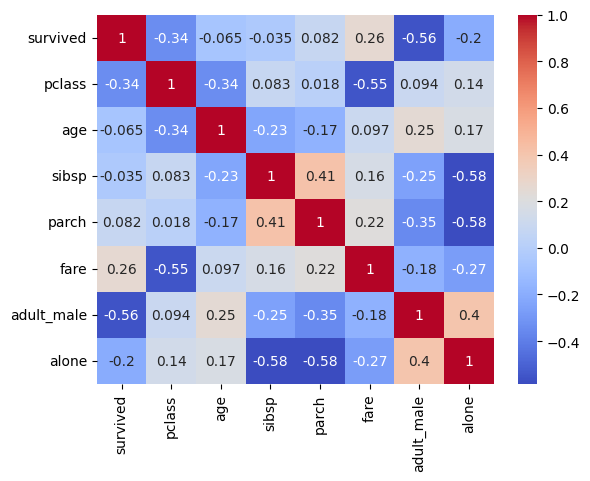

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])




In [ ]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,deck,alone
0,0,3,1,22.0,1,0,7.2500,2,True,NaN,False
1,1,1,0,38.0,1,0,71.2833,0,False,C,False
2,1,3,0,26.0,0,0,7.9250,2,False,NaN,True
3,1,1,0,35.0,1,0,53.1000,2,False,C,False
4,0,3,1,35.0,0,0,8.0500,2,True,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,2,True,NaN,True
887,1,1,0,19.0,0,0,30.0000,2,False,B,True
888,0,3,0,28.0,1,2,23.4500,2,False,NaN,False
889,1,1,1,26.0,0,0,30.0000,0,True,C,True


In [ ]:
df=df.drop(columns=['deck'])

In [ ]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,alone
0,0,3,1,22.0,1,0,7.2500,2,True,False
1,1,1,0,38.0,1,0,71.2833,0,False,False
2,1,3,0,26.0,0,0,7.9250,2,False,True
3,1,1,0,35.0,1,0,53.1000,2,False,False
4,0,3,1,35.0,0,0,8.0500,2,True,True
...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,2,True,True
887,1,1,0,19.0,0,0,30.0000,2,False,True
888,0,3,0,28.0,1,2,23.4500,2,False,False
889,1,1,1,26.0,0,0,30.0000,0,True,True


In [ ]:
df=df.astype(int)

In [ ]:
df


,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,alone
0,0,3,1,22,1,0,7,2,1,0
1,1,1,0,38,1,0,71,0,0,0
2,1,3,0,26,0,0,7,2,0,1
3,1,1,0,35,1,0,53,2,0,0
4,0,3,1,35,0,0,8,2,1,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27,0,0,13,2,1,1
887,1,1,0,19,0,0,30,2,0,1
888,0,3,0,28,1,2,23,2,0,0
889,1,1,1,26,0,0,30,0,1,1


In [ ]:
corr=df.corr(numeric_only=True)

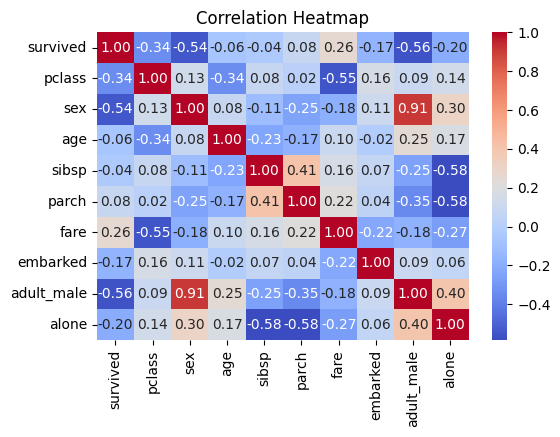

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df.columns


Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'adult_male', 'alone'],
      dtype='object')

In [ ]:
df=df.drop(columns=['adult_male'])

In [ ]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'alone'],
      dtype='object')

In [ ]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22,1,0,7,2,0
1,1,1,0,38,1,0,71,0,0
2,1,3,0,26,0,0,7,2,1
3,1,1,0,35,1,0,53,2,0
4,0,3,1,35,0,0,8,2,1
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27,0,0,13,2,1
887,1,1,0,19,0,0,30,2,1
888,0,3,0,28,1,2,23,2,0
889,1,1,1,26,0,0,30,0,1


In [ ]:
X=df.drop(columns=['survived'])
y=df['survived']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
scaler=StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)

In [ ]:
X_test_scaled = scaler.fit_transform(X_test)

In [ ]:
result=[]

In [ ]:
models={
    "logistic":LogisticRegression(),
    "naive_bayes":GaussianNB(),
    "decision_tree":DecisionTreeClassifier(),
    "svm":SVC(),
    "knn":KNeighborsClassifier()
}

results=[]



In [ ]:
for name,model in models.items():
  model.fit(X_train_scaled,y_train)
  y_pred=model.predict(X_test_scaled)
  acc=accuracy_score(y_test,y_pred)
  f1=f1_score(y_test,y_pred)
  results.append({
      'model':name,
      'accuracy':round(acc,4),
      'f1_score':round(acc,4)
  })

In [ ]:
results

[{'model': 'logistic', 'accuracy': 0.7989, 'f1_score': 0.7989},
 {'model': 'naive_bayes', 'accuracy': 0.7765, 'f1_score': 0.7765},
 {'model': 'decision_tree', 'accuracy': 0.6592, 'f1_score': 0.6592},
 {'model': 'svm', 'accuracy': 0.8101, 'f1_score': 0.8101},
 {'model': 'knn', 'accuracy': 0.8101, 'f1_score': 0.8101}]

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
model_svm=SVC(kernel='rbf')

In [ ]:
model_svm.fit(X_train_scaled,y_train)

SVC()

In [ ]:
y_pred_svc=model_svm.predict(X_test_scaled)

In [ ]:
accuracy_score(y_test,y_pred_svc)

0.8100558659217877

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,y_pred_svc)

array([[93, 12],
       [22, 52]])

In [ ]:
X_scaled=scaler.fit_transform(X)

In [ ]:
score=cross_val_score(model_svm,X_scaled,y,cv=5,scoring='accuracy')

In [ ]:
score

array([0.83240223, 0.82022472, 0.81460674, 0.80898876, 0.87078652])

In [ ]:
print(score.mean())

0.8294017952419811
